# Reconstructing drill sites and paleobathymetry

In this example we generate a video that animates the reconstruction of three drill sites on top of paleobathymetry. The drill sites and paleobathymetry are reconstructed using the Alfonso et al. (2024) plate model from 0 to 170 Ma, a global model including tomotectonic reconstructions of western North America based on Clennett et al. (2020). Since this is not the default plate model in pyBacktrack (Zahirovic 2022), we need to use the `plate_model_manager` module to download the Alfonso 2024 plate model and use it to reconstruct both the paleobathymetry and the drill sites, and also to reconstruct the coastlines and plate boundaries.

Paleobathymetry is reconstructed for preserved ocean floor using pyBacktrack and merged with forward modelled paleobathymetry on subducted crust.

Each reconstructed drill site location is represented by a coloured symbol. The two sites on continental crust are `DSDP-36-327` (red triangle) and `sunrise` (purple square). The site on oceanic crust is `ODP-114-699` (yellow circle). The `sunrise` site is backstripped (instead of backtracked) because it has a record of paleo water depths and hence does not need a model of tectonic subsidence to infer them.

The animation also displays the compaction of stratigraphic layers at each drill site. As new layers are deposited over time the underlying layers compact. The first layer represents the water depth (rendered in blue). Then the individual stratigraphic layers are rendered with a set of hardwired colours that are repeated (if there are more layers in the drill site than hardwired colours). Finally, the basement layer (from bottom of drill site to basement depth) is rendered in grey. A basement layer only exists if the total sediment thickness (at the drill site) is deeper than the drill site. A basement layer is more likely to exist (and likely to be thicker) at continental drill sites because the default total sediment thickness grid is not as accurate near continental margins (compared to deeper ocean basins).

The reconstructed coastlines and plate boundaries are rendered using GPlately. The reconstructed paleobathymetry grids are also read and rendered using GPlately.

> **Note:** This notebook was used to create the release video for pyBacktrack 1.5.

Here is a snapshot of that video at 40 Ma:

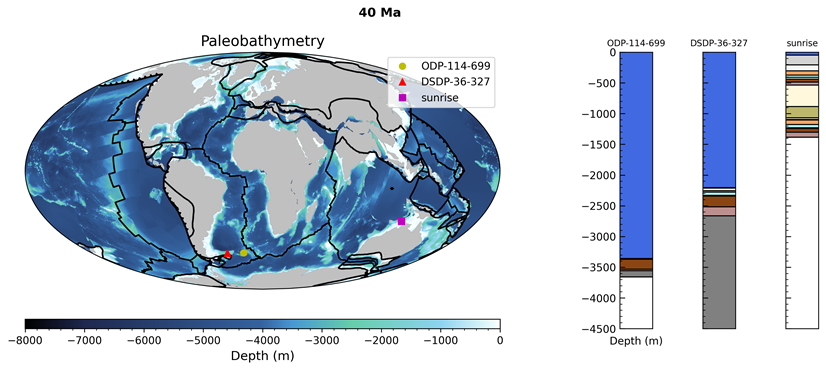

PyBacktrack can perform the merging of *traditional* paleobathymetry (forward modelled paleobathymetry on subducted crust). We show how to do that in this notebook. Enabling this merging will fill in regions where pyBacktrack does not reconstruct paleobathymetry. However, it is currently disabled since the Alfonso 2024 _traditional_ paleobathymetry grids (used for the release video) are not publicly available. But you can still enable merging if you have your own traditional paleobathymetry grids.

Alternatively, we provide download links to traditional and merged paleobathymetry for the Zahirovic 2022 plate model (the default plate model in pyBacktrack).

Traditional paleobathymetry for the Zahirovic 2022 plate model for ages 0 to 410 Ma:

* In the [paleomagnetic reference frame](https://repo.gplates.org/webdav/PlateModel_Age_SR_Grids/Zahirovic_etal_2022_GDJ/02_AgegridsUsingTopologies/PaleomagneticFrame/PaleobathymetryGrids/traditional/GDH1/) (anchor plate `701701`).
* In the [mantle reference frame](https://repo.gplates.org/webdav/PlateModel_Age_SR_Grids/Zahirovic_etal_2022_GDJ/02_AgegridsUsingTopologies/OptimisedMantleFrame/PaleobathymetryGrids/traditional/GDH1/) (anchor plate `0`).

And merged paleobathymetry for the Zahirovic 2022 plate model for ages 0 to 170 Ma (where 170 Ma is roughly when backtracked present-day crust no longer exists back in time):

* In the [paleomagnetic reference frame](https://repo.gplates.org/webdav/PlateModel_Age_SR_Grids/Zahirovic_etal_2022_GDJ/02_AgegridsUsingTopologies/PaleomagneticFrame/PaleobathymetryGrids/pybacktrack/GDH1/) (anchor plate `701701`).
* In the [mantle reference frame](https://repo.gplates.org/webdav/PlateModel_Age_SR_Grids/Zahirovic_etal_2022_GDJ/02_AgegridsUsingTopologies/OptimisedMantleFrame/PaleobathymetryGrids/pybacktrack/GDH1/) (anchor plate `0`).

...please see the `paleobathymetry` notebook for more details on merging traditional paleobathymetry.

## Reference

The following paper covers the theory and algorithms of pyBacktrack:

* Müller, R. D., Cannon, J., Williams, S. and Dutkiewicz, A., 2018,
  PyBacktrack 1.0: A Tool for Reconstructing Paleobathymetry on Oceanic and Continental Crust,
  **Geochemistry, Geophysics, Geosystems,** 19, 1898-1909, doi: [10.1029/2017GC007313](https://doi.org/10.1029/2017GC007313)

### Import Required Libraries

Import the necessary libraries including cartopy for map projections, GPlately for visualizing paleobathymetry and reconstructed coastlines and plate boundaries, plate model manager for loading plate models, matplotlib for visualization, and joblib for parallel processing.

In [ ]:
import cartopy.crs as ccrs
import gplately
from joblib import Parallel, delayed
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
from plate_model_manager import PlateModelManager
import pybacktrack
import os
import sys

### Create Output Directory

Set up the output directory structure for storing reconstructed paleobathymetry grids, snapshots, and videos.

In [ ]:
output_directory = os.path.join("NotebookFiles", "reconstruct_drill_sites_on_paleobathymetry")
os.makedirs(output_directory, exist_ok=True)

### Load Plate Model and Reconstruction Data

Fetch the Alfonso2024 plate model and its associated rotation data, topology features, static polygons, coastlines, and continental geometry from the plate model manager.

In [ ]:
# Obtain all rotation files, topology features and static polygons from Alfonso2024 via the plate model manager.
pm_manager = PlateModelManager()
plate_model = pm_manager.get_model(
    "Alfonso2024",
    data_dir=os.path.join("NotebookFiles", "plate-model-repo"))
rotation_model = plate_model.get_rotation_model()
topology_features = plate_model.get_topologies()
static_polygons = plate_model.get_static_polygons()

model = gplately.PlateReconstruction(rotation_model, topology_features, static_polygons)

# Obtain the coastlines.
coastlines = plate_model.get_coastlines()
continents = plate_model.get_continental_polygons()

gplot = gplately.PlotTopologies(model, coastlines=coastlines, continents=continents)

### Set Reconstruction Parameters

Configure the time range (170 to 0 Ma), grid spacing, dynamic topography model, age-to-depth model, and number of CPUs for paleobathymetry reconstruction.

In [ ]:
oldest_time = 170  # Alfonso2024 plate model starts at 170 Ma (otherwise we'd start at 190 Ma)
youngest_time = 0
time_increment = 1
time_range = np.arange(oldest_time, youngest_time-0.5*time_increment, -time_increment)

grid_spacing_degrees = 0.2

dynamic_topography_model_name = None  # 'M7'  # use None for no dynamic topography

ocean_age_to_depth_model = pybacktrack.AGE_TO_DEPTH_MODEL_GDH1

ncpus = 4

### Generate Paleobathymetry Grids

Create paleobathymetry grids for the entire time range using pyBacktrack.

We can optionally merge these grids with traditional paleobathymetry grids that include subducted oceanic crust. PyBacktrack does not reconstruct paleobathymetry on synthetic crust that is subducted at present day. This means the traditional grids will fill in paleobathymetry in regions where crust has been subducted at present day.

Traditional paleobathymetry grids must be produced by an external workflow that generates paleobathymetry for synthetic crust. This notebook was used to create the release video for pyBacktrack 1.5. For that video we used Nicky Wright's traditional paleobathymetry workflow, which includes reconstructed (conjugate) LIPS (ie oceanic plateaus). It is currently in a [private repository](https://github.com/EarthByte/paleobathymetry-workflow) (that might be incorporated into [GPlately](https://github.com/GPlates/gplately/) in the future). The traditional Alfonso 2024 paleobathymetry grids used for the video are not publicly available. Hence the merging of traditional paleobathymetry is currently disabled in this notebook (with `merge_paleo_bathymetry = False`).

However, there are traditional and merged paleobathymetry grids available for the Zahirovic 2022 plate model (the default plate model in pyBacktrack).

Traditional paleobathymetry for the Zahirovic 2022 plate model (for ages 0 to 410 Ma):

* In the [paleomagnetic reference frame](https://repo.gplates.org/webdav/PlateModel_Age_SR_Grids/Zahirovic_etal_2022_GDJ/02_AgegridsUsingTopologies/PaleomagneticFrame/PaleobathymetryGrids/traditional/GDH1/) (anchor plate `701701`).
* In the [mantle reference frame](https://repo.gplates.org/webdav/PlateModel_Age_SR_Grids/Zahirovic_etal_2022_GDJ/02_AgegridsUsingTopologies/OptimisedMantleFrame/PaleobathymetryGrids/traditional/GDH1/) (anchor plate `0`).

And merged paleobathymetry for the Zahirovic 2022 plate model (for ages 0 to 410 Ma):

* In the [paleomagnetic reference frame](https://repo.gplates.org/webdav/PlateModel_Age_SR_Grids/Zahirovic_etal_2022_GDJ/02_AgegridsUsingTopologies/PaleomagneticFrame/PaleobathymetryGrids/pybacktrack/GDH1/) (anchor plate `701701`).
* In the [mantle reference frame](https://repo.gplates.org/webdav/PlateModel_Age_SR_Grids/Zahirovic_etal_2022_GDJ/02_AgegridsUsingTopologies/OptimisedMantleFrame/PaleobathymetryGrids/pybacktrack/GDH1/) (anchor plate `0`).

...please see the `paleobathymetry` notebook for more details on merging traditional paleobathymetry.

In [ ]:
# Set this to True to enable merging of the paleobathymetry grids generated by pyBacktrack
# with traditional paleobathymetry grids.
#
# Note: If you do then you'll need to provide your own traditional grid files and specify their location
#       in the 'merge_paleo_bathymetry_filename_format' variable below.
merge_paleo_bathymetry = False

if merge_paleo_bathymetry:
    # The paleobathymetry grids to merge with those generated by pyBacktrack.
    #
    # They contain paleobathymetry for *subducted* oceanic crust
    # (unlike pyBacktrack which only generates paleobathymetry for crust that still exists at *present day*).
    #
    # The filename format must contain "${time}" in it - in order to generate a filename for each reconstruction time.
    #
    # NOTE: This path does not actually exist - it was only used to generate the pyBacktrack 1.5 release video.
    #       If you are merging then you'll need to provide your own traditional paleobathymetry and specify its path here.
    merge_paleo_bathymetry_filename_format = os.path.join(
        "NotebookFiles",
        "reconstruct_drill_sites_on_paleobathymetry",
        "TraditionalPaleobathymetry",
        "Alfonso2024_GDH1_D17_LIPs",
        'paleobathymetry_${time}Ma.nc')
    # Replace "${time}" with the reconstruction time accurate to zero decimal places.
    merge_paleo_bathymetry_file_decimal_places_in_time = 0
else:
    merge_paleo_bathymetry_filename_format = None
    merge_paleo_bathymetry_file_decimal_places_in_time = 0

# Generate paleobathymetry grids using pyBacktrack, and also merge them with the external paleobathymetry grids (if requested).
pybacktrack.reconstruct_paleo_bathymetry_grids(
    output_file_prefix=os.path.join(output_directory, 'paleo_bathymetry'),
    grid_spacing_degrees=grid_spacing_degrees,
    oldest_time=oldest_time,
    time_increment=time_increment,
    youngest_time=youngest_time,
    rotation_filenames=rotation_model,
    static_polygon_filename=static_polygons[0],
    dynamic_topography_model=dynamic_topography_model_name,
    ocean_age_to_depth_model=ocean_age_to_depth_model,
    merge_paleo_bathymetry_filename_format=merge_paleo_bathymetry_filename_format,
    merge_paleo_bathymetry_file_decimal_places_in_time=merge_paleo_bathymetry_file_decimal_places_in_time,
    use_all_cpus=ncpus)

# The paleobathymetry grid filenames are generated from this format using "paleo_bathymetry_filename_format.format(time)".
# By default, "_<time>.nc" is appended to the output file prefix (with <time> formatted to 1 decimal place).
paleo_bathymetry_filename_format = os.path.join(output_directory, 'paleo_bathymetry_{:.1f}.nc')

### Backtrack and Backstrip Drill Sites

Backtrack/backstrip three drill sites to obtain a history of paleo water depths and decompacted stratigraphic layers over time, in increments of one million years (1 Myr).

Backtrack oceanic drill site `ODP-114-699` from the time of oceanic crust formation (at the drill site) to present day. Backtrack continent drill site `DSDP-36-327` from the time that continental rifting started to present day. And backstrip continent drill site `sunrise` from when sediment deposition was first recorded in that drill site to present day. The last drill site `sunrise` is backstripped (instead of backtracked) because it has a record of paleo water depths and hence does not need a model of tectonic subsidence to infer them.

In [ ]:
pybacktrack_example_data_dir = os.path.join('..', 'example_data')


all_decompacted_well_names = []
all_decompacted_wells_by_name = {}

#
# Backtrack 'ODP-114-699' oceanic drill site.
#
ODP_114_699_well_name = 'ODP-114-699'
# From ocean crust formation (at drill site) to present day...
ODP_114_699_times = np.arange(0, 80+1, time_increment)
_, ODP_114_699_decompacted_well_at_times = pybacktrack.backtrack_well(
    os.path.join(pybacktrack_example_data_dir, 'ODP-114-699-Lithology.txt'),
    times=ODP_114_699_times,
    rotation_filenames=rotation_model,
    static_polygon_filename=static_polygons[0],
    dynamic_topography_model=dynamic_topography_model_name,
    ocean_age_to_depth_model=ocean_age_to_depth_model)
all_decompacted_well_names.append(ODP_114_699_well_name)
all_decompacted_wells_by_name[ODP_114_699_well_name] = { dw.get_age() : dw for dw in ODP_114_699_decompacted_well_at_times }

#
# Backtrack 'DSDP-36-327' continental drill site.
#
DSDP_36_327_well_name = 'DSDP-36-327'
# From rift start to present day.
DSDP_36_327_times = np.arange(0, 160+1, time_increment)
_, DSDP_36_327_decompacted_well_at_times = pybacktrack.backtrack_well(
    os.path.join(pybacktrack_example_data_dir, 'DSDP-36-327-Lithology.txt'),
    times=DSDP_36_327_times,
    rotation_filenames=rotation_model,
    static_polygon_filename=static_polygons[0],
    dynamic_topography_model=dynamic_topography_model_name,
    ocean_age_to_depth_model=ocean_age_to_depth_model)
all_decompacted_well_names.append(DSDP_36_327_well_name)
all_decompacted_wells_by_name[DSDP_36_327_well_name] = { dw.get_age() : dw for dw in DSDP_36_327_decompacted_well_at_times }

#
# Backstrip 'sunrise' continental drill site.
#
# Note: Backstripping (instead of backtracking because it has recorded paleo water depths).
#
sunrise_well_name = 'sunrise'
# From bottom age of drill site to present day.
sunrise_times = np.arange(0, 190+1, time_increment)
_, sunrise_decompacted_well_at_times = pybacktrack.backstrip_well(
    os.path.join(pybacktrack_example_data_dir, 'sunrise_lithology.txt'),
    times=sunrise_times,
    rotation_filenames=rotation_model,
    static_polygon_filename=static_polygons[0],
    # Read all the bundled lithologies ("primary" and "extended") since
    # drill site contains 'Dolostone' which is in "extended"...
    lithology_filenames=pybacktrack.BUNDLE_LITHOLOGY_FILENAMES)
all_decompacted_well_names.append(sunrise_well_name)
all_decompacted_wells_by_name[sunrise_well_name] = { dw.get_age() : dw for dw in sunrise_decompacted_well_at_times }

### Import CPT Color Palette for Bathymetry Visualization

Load the GMT bathymetry color palette from `GMT_bathy.cpt` to create a color mapping for the paleobathymetry depth visualization.

In [ ]:
# This function was adapted from https://gplates.github.io/gplately/latest/notebook-html/13-ReconstructingZirconData.html
def import_cpt(filename, cmap_name):
    colors = []
    positions = []

    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()

            # Skip comments or special lines
            if not line or line.startswith('#') or line[0] in ('B', 'F', 'N'):
                continue

            parts = line.split()
            
            # FORMAT A: Slash-separated RGB like 255/255/0
            if len(parts) >= 4 and ('/' in parts[1] or '/' in parts[3]):
                
                pos1 = float(parts[0])
                try:
                    r1, g1, b1 = map(float, parts[1].split('/'))
                except ValueError:
                    # Could be a named colour, or hex string, etc.
                    r1, g1, b1 = (c * 255 for c in mcolors.to_rgb(parts[1]))
                
                pos2 = float(parts[2])
                try:
                    r2, g2, b2 = map(float, parts[3].split('/'))
                except ValueError:
                    # Could be a named colour, or hex string, etc.
                    r2, g2, b2 = (c * 255 for c in mcolors.to_rgb(parts[3]))

            # FORMAT B: Space-separated RGB
            elif len(parts) >= 8:
                
                pos1 = float(parts[0])
                r1, g1, b1 = map(float, parts[1:4])
                
                pos2 = float(parts[4])
                r2, g2, b2 = map(float, parts[5:8])

            else:
                raise ValueError(f"Unrecognised format of line in CPT file: {line}")

            # Add both ends of the segment
            positions.extend([pos1, pos2])
            colors.extend([
                (r1/255, g1/255, b1/255),
                (r2/255, g2/255, b2/255)
            ])

    if len(positions) == 0:
        raise ValueError("No color stops found in CPT file.")

    # Normalize to [0, 1]
    positions = np.array(positions)
    positions = (positions - positions.min()) / (positions.max() - positions.min())

    return mcolors.LinearSegmentedColormap.from_list(cmap_name, list(zip(positions, colors)))

bathymetry_cmap = import_cpt('./NotebookFiles/GMT_bathy.cpt', cmap_name='gmt/bathy')

### Define Plotting Function for Reconstructed Paleobathymetry and Drill Sites

This function animates the reconstructed paleobathymetry and reconstructed drill sites from 0 to 170 Ma (the time range of the Alfonso 2024 model).

Each reconstructed drill site location is represented by a coloured symbol. And the reconstructed coastlines and plate boundaries are rendered using GPlately. The reconstructed paleobathymetry grids are also read and rendered using GPlately.

Additionally, a plot of the stratigraphic depth layers at each drill site is animated as new layers are deposited over time and the underlying layers compact. First the water depth is rendered in blue. Then the individual stratigraphic layers are rendered with a set of hardwired colours that are cycled through multiple times (if there are more layers than colours). And finally the basement layer (from bottom of drill site to basement depth) is rendered in grey, if a basement layer exists. A basement layer only exists if the total sediment thickness (at the drill site) is deeper than the drill site. A basement layer is more likely to exist, and likely to be thicker, at _continental_ drill sites because the default total sediment thickness grid is not as accurate near continental margins (compared to deeper ocean basins).

In [ ]:
def plot(time, save_fig=False):
    """Plot reconstructed drill sites with paleobathymetry at the specified time."""

    # How much wider the paleobathymetry plot is compared to a single drill site (layers) plot.
    paleobathymetry_plot_width_multiplier = 8
    
    fig = plt.figure(figsize=(12,5), dpi=200)
    plt.suptitle(f"{time:.0f} Ma", weight="demi")
    gs = fig.add_gridspec(1, paleobathymetry_plot_width_multiplier + len(all_decompacted_wells_by_name))
    
    #
    # Plot paleobathymetry.
    #
    
    ax_paleobathymetry = fig.add_subplot(
        gs[0, :paleobathymetry_plot_width_multiplier],
        projection=ccrs.Mollweide(central_longitude=0.0))
    ax_paleobathymetry.set_title("Paleobathymetry", fontsize=14)

    # Continent and background colours.
    continent_color = 'silver'
    if merge_paleo_bathymetry:
        # Set the background color the same as the continent color.
        # This helps fill in the areas where the continents are deforming (like Andes) but
        # this is not represented in the reconstructed continent polygons (whose shape is *static*).
        background_color = continent_color
    else:
        # We're not merging paleobathymetry, so there'll be large areas of ocean crust missing paleobathymetry.
        # So use a darker grey (than the continents) for the background (ie, it shouldn't look like continents).
        background_color = 89.0/255, 89.0/255, 89.0/255
    # Set the background color of the axes to grey.
    ax_paleobathymetry.set_facecolor(background_color)
    
    # Load paleobathymetry generated by pyBacktrack (optionally merged with the external paleobathymetry grids).
    paleo_bathymetry = gplately.Raster(paleo_bathymetry_filename_format.format(time))
    # Note: Give paleobathymetry a zorder of 1 so it gets drawn *above* the continents (zorder=0).
    pb = paleo_bathymetry.imshow(ax_paleobathymetry, cmap=bathymetry_cmap, vmin=-8000, vmax=0, zorder=1)

    # Set a colorbar for the paleobathymetry.
    ax_paleobathymetry_divider = make_axes_locatable(ax_paleobathymetry)
    cax_paleobathymetry = ax_paleobathymetry_divider.append_axes("bottom", size="4%", pad=0.4, axes_class=plt.Axes)
    fig.add_axes(cax_paleobathymetry)
    cbar = plt.colorbar(pb, cax=cax_paleobathymetry, orientation="horizontal")
    cbar.set_label('Depth (m)', fontsize=12)
    cbar.ax.minorticks_on()

    # Set gplot.time to current time to automatically rotate all features to the current time.
    gplot.time = time

    # Plot plate motion vectors, continents, trenches and subduction teeth.
    #
    # Note: Give continents a zorder of 0 so it gets drawn *underneath* the paleobathymetry (zorder=1).
    gplot.plot_coastlines(ax_paleobathymetry, facecolor=continent_color, edgecolor='none', zorder=0)
    gplot.plot_trenches(ax_paleobathymetry, zorder=2)
    gplot.plot_subduction_teeth(ax_paleobathymetry, zorder=2)
    
    # Plot all other topological sections other than trenches or ridges.
    gplot.plot_all_topological_sections(ax_paleobathymetry)

    #
    # Plot decompacted sediment layers for drill sites.
    #

    def plot_well(time, well_name, well_index, well_marker_fmts, is_leftmost_well, decompacted_well):

        # Plot the reconstructed well location at 'time'.
        ax_paleobathymetry.plot(
            decompacted_well.paleo_longitude,
            decompacted_well.paleo_latitude,
            well_marker_fmts,
            label=well_name,
            transform=ccrs.PlateCarree())

        # Only leftmost well needs the depth labels.
        if is_leftmost_well:
            sediment_layers_labelleft = True
            sediment_layers_xlabel = 'Depth (m)'
        else:
            sediment_layers_labelleft = False
            sediment_layers_xlabel = None
        
        ax_sediment_layers = fig.add_subplot(
            gs[0, paleobathymetry_plot_width_multiplier+well_index:paleobathymetry_plot_width_multiplier+well_index+1],
            xlim=[0, 1],
            ylim=[-4500.0, 0.0])
        ax_sediment_layers.set_title(well_name, fontsize='small')
        ax_sediment_layers.set_xlabel(sediment_layers_xlabel)
        ax_sediment_layers.tick_params(direction="in", length=5, labelleft=sediment_layers_labelleft, top=False, bottom=False, labelbottom=False)
        ax_sediment_layers.tick_params(direction="in", which='minor', labelleft=sediment_layers_labelleft, length=2.5, top=False, bottom=False)
        ax_sediment_layers.minorticks_on()
        
        # For each drill site plot its decompacted sediment layers.
    
        #lithology_colours = {
        #    'Shale' : 'darkkhaki',
        #    'Diatomite' : 'cornsilk',
        #    'Clay' : 'rosybrown',
        #    'Coccolith_ooze' : 'white',
        #    'Mud' : 'saddlebrown',
        #    'Sand' : 'lightyellow',
        #    'Biogenic_sand' : 'paleturquoise',
        #    'Shaley_sand' : 'sandybrown',
        #    'Chalk' : 'whitesmoke',
        #    'Dolostone' : 'lightgrey',
        #    'Limestone' : 'beige',
        #}
        
        # Choose a colour for each (non-basement) stratigraphic unit.
        stratigraphic_unit_colours = [
            'darkkhaki',
            'cornsilk',
            'rosybrown',
            'saddlebrown',
            'lightyellow',
            'paleturquoise',
            'sandybrown',
            'whitesmoke',
            'lightgrey',
            'beige',
        ]

        # Colour for basement stratigraphic unit (if present) - from bottom of drill site to basement depth.
        basement_stratigraphic_unit_colour = 'grey'
        
        num_decompacted_stratigraphic_units = len(decompacted_well.decompacted_stratigraphic_units)

        #
        # NOTE: Drill site depths are usually positive.
        #       But we negate them to be consistent with the paleobathymetry grids where bathymetry is typically negative.
        #
        
        # Plot the water depth.
        decompacted_layer_top_depth = -decompacted_well.get_water_depth()
        plt.stairs(
            (0.0,),
            (0.0, 1.0),
            baseline=decompacted_layer_top_depth,
            fill=True,
            facecolor='royalblue')

        # Plot the stratigraphic unit depths.
        for decompacted_stratigraphic_unit_index, decompacted_stratigraphic_unit in enumerate(decompacted_well.decompacted_stratigraphic_units):
            decompacted_layer_bottom_depth = decompacted_layer_top_depth - decompacted_stratigraphic_unit.decompacted_thickness

            # If it's the basement layer (last layer with only the base lithology component) then use a distinct colour.
            if (decompacted_stratigraphic_unit_index == num_decompacted_stratigraphic_units - 1 and
                decompacted_stratigraphic_unit.stratigraphic_unit.lithology_components == [(pybacktrack.DEFAULT_BASE_LITHOLOGY_NAME, 1.0)]):
                unit_color=basement_stratigraphic_unit_colour
            else:
                unit_color_index = num_decompacted_stratigraphic_units - decompacted_stratigraphic_unit_index
                unit_color=stratigraphic_unit_colours[unit_color_index % len(stratigraphic_unit_colours)]
            
            plt.stairs(
                (decompacted_layer_top_depth,),
                (0.0, 1.0),
                baseline=decompacted_layer_bottom_depth,
                fill=True,
                facecolor=unit_color)
            
            plt.stairs(
                (decompacted_layer_top_depth,),
                (0.0, 1.0),
                baseline=None,
                edgecolor='black')
            
            # For next iteration.
            decompacted_layer_top_depth = decompacted_layer_bottom_depth
            
        plt.stairs(
            (decompacted_layer_top_depth,),
            (0.0, 1.0),
            baseline=None,
            edgecolor='black')


    # Cycle between markers (style and colour).
    well_marker_fmts = ['oy', '^r', 'sm']

    is_leftmost_well = True  # first well plotted is the leftmost well
    for well_index, well_name in enumerate(all_decompacted_well_names):
        # Get the decompacted well at 'time'.
        decompacted_well = all_decompacted_wells_by_name[well_name].get(time)
        # If well (or crust it's on) has appeared at 'time'.
        if decompacted_well:
            plot_well(
                time,
                well_name,
                well_index,
                well_marker_fmts[well_index % len(well_marker_fmts)],
                is_leftmost_well,
                decompacted_well)
            is_leftmost_well = False  # next well plotted is not leftmost

    ax_paleobathymetry.legend()

    plt.tight_layout()

    
    if save_fig:
        fig.savefig(
            os.path.join(output_directory, f"snapshot_{time:.1f}.png"),
            dpi=300,
            bbox_inches='tight')
    else:
        plt.show()

    plt.close()

### Test Plot at a Single Time Snapshot

Create a test visualization at 40 Ma to verify the plot function works correctly before generating all time steps.

In [ ]:
plot(time=40)

### Generate Paleobathymetry Snapshots for All Time Steps

Create visualization snapshots for each time step in the reconstruction. This can be done in parallel to speed up processing of all time intervals.

In [ ]:
use_parallel = True

if use_parallel:
    # Produce plots in a parallel routine - a progress bar and time taken will be shown.
    parallel_plots = Parallel(n_jobs=ncpus, verbose=1)(
    delayed(plot) (time, save_fig=True) for time in time_range)

else:
    for time in time_range:
        plot(time, save_fig=True)

### Create Video from Paleobathymetry Snapshots

Combine all the individual snapshot images into a video file using moviepy, with proper codec settings for MP4 format.

In [ ]:
try:
    import moviepy.editor as mpy  # moviepy 1.x
except ImportError:
    import moviepy as mpy  # moviepy 2.x

frame_list = []
for time in time_range:
    frame_list.append(
        os.path.join(output_directory, f"snapshot_{time:.1f}.png")
    )
    
clip = mpy.ImageSequenceClip(frame_list, fps=20)

clip.write_videofile(
    os.path.join(output_directory, "reconstruct_drill_sites_on_paleobathymetry.mp4"),
    fps=20,
    codec="libx264",
    bitrate="8000k",
    audio=False,
    logger=None,
    ffmpeg_params=[
        "-vf",
        "pad=ceil(iw/2)*2:ceil(ih/2)*2",
        "-pix_fmt",
        "yuv420p",
    ],
)

### Create Animated GIF from Frames

Convert the reconstructed frames into an animated GIF file for visualization in this notebook cell.

In [ ]:
plot_animated_gif = True

if plot_animated_gif:
    from IPython.display import Image

    gif_filename = os.path.join(output_directory, "reconstruct_drill_sites_on_paleobathymetry.gif")
    
    clip.write_gif(gif_filename)
    
    with open(gif_filename, "rb") as f:
        display(Image(data=f.read(), format='gif', width = 3000, height = 1000))